importation des bibliotheques

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

Charger le dataset

In [3]:
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    usecols=["Date", "Time", "Global_active_power"],
    na_values=["?"],
    low_memory=False
)

df.head()

,Date,Time,Global_active_power
0,16/12/2006,17:24:00,4.216
1,16/12/2006,17:25:00,5.360
2,16/12/2006,17:26:00,5.374
3,16/12/2006,17:27:00,5.388
4,16/12/2006,17:28:00,3.666


Nettoyer et créer la date

In [4]:
df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

df["Global_active_power"] = pd.to_numeric(
    df["Global_active_power"],
    errors="coerce"
)

df = df.dropna(subset=["datetime", "Global_active_power"])
df = df.set_index("datetime").sort_index()

df.head()

,Date,Time,Global_active_power
datetime,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666


Créer la version horaire

In [5]:
hourly = (
    df["Global_active_power"]
    .resample("h")
    .mean()
    .dropna()
    .rename("consumption")
    .to_frame()
)

hourly.head()

,consumption
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


Ajouter les variables utilisées par le modèle final

In [6]:
hourly["lag_1"] = hourly["consumption"].shift(1)
hourly["lag_24"] = hourly["consumption"].shift(24)

hourly["hour"] = hourly.index.hour
hourly["day_of_week"] = hourly.index.dayofweek
hourly["month"] = hourly.index.month
hourly["day_of_year"] = hourly.index.dayofyear

hourly = hourly.dropna()

hourly.head()

,consumption,lag_1,lag_24,hour,day_of_week,month,day_of_year
datetime,,,,,,,
2006-12-17 17:00:00,3.406767,3.326033,4.222889,17,6,12,351
2006-12-17 18:00:00,3.697100,3.406767,3.632200,18,6,12,351
2006-12-17 19:00:00,2.908400,3.697100,3.400233,19,6,12,351
2006-12-17 20:00:00,3.361500,2.908400,3.268567,20,6,12,351
2006-12-17 21:00:00,3.040767,3.361500,3.056467,21,6,12,351


Préparer X et y

In [7]:
features = ["lag_1", "lag_24", "hour", "day_of_week", "month", "day_of_year"]

X = hourly[features]
y = hourly["consumption"]

split_index = int(len(hourly) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

len(X_train), len(X_test)

(27315, 6829)

Entraîner les deux modèles

In [8]:
models = {
    "Régression linéaire": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=60,
        max_depth=14,
        random_state=42,
        n_jobs=1
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    results.append({
        "Modèle": name,
        "MAE": mae,
        "RMSE": rmse
    })

results_df = pd.DataFrame(results)
results_df

,Modèle,MAE,RMSE
0,Régression linéaire,0.381502,0.532072
1,Random Forest,0.335487,0.486440


Identifier le modèle retenu

In [9]:
best_model = results_df.sort_values("RMSE").iloc[0]
best_model

Modèle    Random Forest
MAE            0.335487
RMSE            0.48644
Name: 1, dtype: object

Graphique MAE/RMSE 

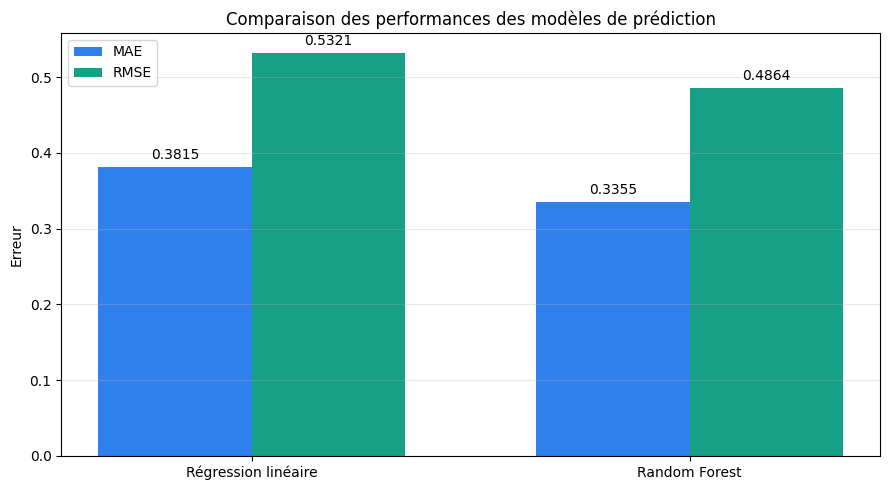

In [10]:
plt.figure(figsize=(9, 5))

x = np.arange(len(results_df["Modèle"]))
width = 0.35

plt.bar(x - width/2, results_df["MAE"], width, label="MAE", color="#2f80ed")
plt.bar(x + width/2, results_df["RMSE"], width, label="RMSE", color="#16a085")

plt.xticks(x, results_df["Modèle"])
plt.ylabel("Erreur")
plt.title("Comparaison des performances des modèles de prédiction")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for i, row in results_df.iterrows():
    plt.text(i - width/2, row["MAE"] + 0.01, f"{row['MAE']:.4f}", ha="center")
    plt.text(i + width/2, row["RMSE"] + 0.01, f"{row['RMSE']:.4f}", ha="center")

plt.tight_layout()
plt.savefig("comparaison_modeles_prediction.png", dpi=300)
plt.show()

Graphique réel vs prédiction Random Forest

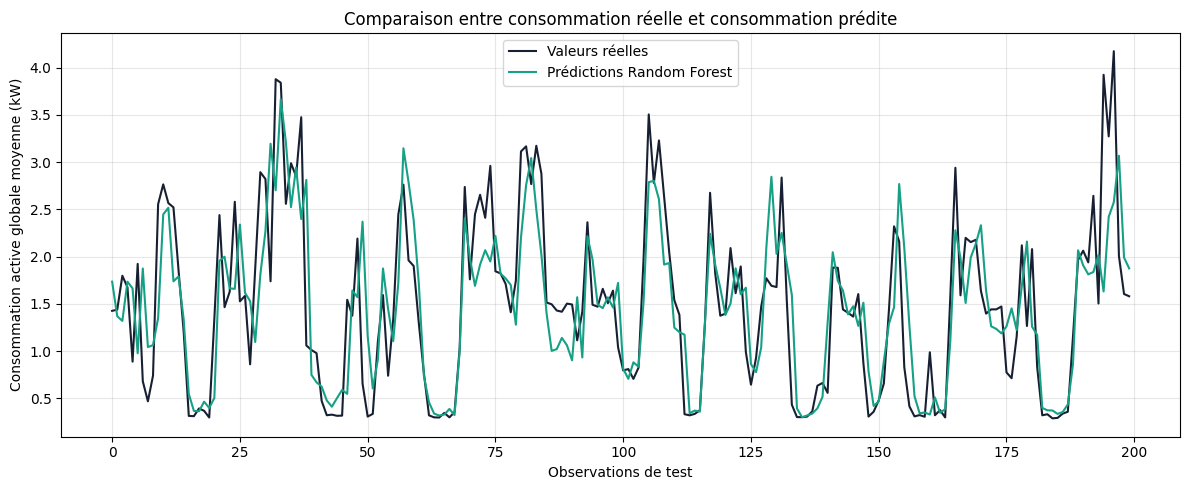

In [11]:
rf_model = models["Random Forest"]
y_pred_rf = rf_model.predict(X_test)

plt.figure(figsize=(12, 5))

plt.plot(y_test.values[:200], label="Valeurs réelles", color="#172033")
plt.plot(y_pred_rf[:200], label="Prédictions Random Forest", color="#16a085")

plt.title("Comparaison entre consommation réelle et consommation prédite")
plt.xlabel("Observations de test")
plt.ylabel("Consommation active globale moyenne (kW)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("prediction_random_forest_vs_reel.png", dpi=300)
plt.show()